# 中芯国际(港股)技术指标计算实验室
## Task02 — RSI / MACD / 布林带 / ATR

| 项目 | 内容 |
|------|------|
| **标的** | 中芯国际 00981.HK (港股) / 688981.SH (A股备用) |
| **数据源** | Tushare Pro |
| **回溯区间** | 2023-01-01 ~ 2026-07-04 |
| **指标** | RSI(14) / MACD(12,26,9) / 布林带(20,2σ) / ATR(14) |
| **日期** | 2026-07-04 |

> **数据源说明**: 由于当前 Tushare token 的 `hk_daily` 接口限频为 1次/小时，
> 港股数据配额已用尽。按 spec 降级策略，本 notebook 使用 A 股 688981.SH
> (中芯国际科创板) 日线数据作为替代。两者为同一公司不同市场上市，
> 技术指标计算方法完全一致。

In [1]:
# === 环境初始化 ===
import os
import warnings
import tushare as ts
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings('ignore')

# --- matplotlib 中文字体与风格 ---
plt.style.use('seaborn-v0_8-whitegrid')
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['savefig.dpi'] = 150
matplotlib.rcParams['figure.figsize'] = (14, 8)

# --- 中国惯例配色: 红涨绿跌 ---
COLOR_UP   = '#E24B4A'   # 红色(涨)
COLOR_DOWN = '#639922'   # 绿色(跌)
COLOR_PRICE = '#378ADD'  # 蓝色(价格线)
COLOR_SIGNAL = '#7F77DD' # 紫色(信号线)
COLOR_ACCENT = '#BA7517' # 橙色(辅助)
FILL_ALPHA = 0.15

# --- Tushare 初始化 ---
TOKEN = os.getenv('TUSHARE_TOKEN', '7b488644550ffbfc3abbaf72172a97a9eab3b5eb7c526253a7d46c81')
ts.set_token(TOKEN)
pro = ts.pro_api()

# --- 路径配置 ---
BASE_DIR = os.path.dirname(os.path.abspath('.')) if '__file__' not in dir() else os.path.dirname(os.path.abspath(__file__))
DATA_DIR = os.path.join('.', 'data')
FIG_DIR = os.path.join('.', 'figures')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("环境初始化完成")
print(f"  tushare: {ts.__version__}")
print(f"  pandas:  {pd.__version__}")
print(f"  matplotlib: {matplotlib.__version__}")
print(f"  数据目录: {DATA_DIR}")
print(f"  图表目录: {FIG_DIR}")

环境初始化完成
  tushare: 1.4.29
  pandas:  3.0.3
  matplotlib: 3.11.0
  数据目录: .\data
  图表目录: .\figures


In [2]:
# === 数据获取 ===
# 策略: 优先港股 hk_daily -> 降级 A 股 pro.daily -> 读取已有CSV

CSV_PATH = os.path.join(DATA_DIR, '00981HK_daily.csv')
START_DATE = '20230101'
END_DATE = '20260704'

def fetch_hk_data():
    """尝试获取港股 00981.HK 数据"""
    try:
        df = pro.hk_daily(ts_code='00981.HK', start_date=START_DATE, end_date=END_DATE)
        if df is not None and not df.empty:
            print(f"[OK] 港股 hk_daily 获取成功: {len(df)} 行")
            return df, '00981.HK (港股)'
    except Exception as e:
        print(f"[SKIP] hk_daily 不可用: {str(e)[:60]}")
    return None, None

def fetch_a_share_data():
    """降级: 获取 A 股 688981.SH 数据"""
    try:
        df = pro.daily(ts_code='688981.SH', start_date=START_DATE, end_date=END_DATE)
        if df is not None and not df.empty:
            print(f"[OK] A股 pro.daily 获取成功: {len(df)} 行")
            return df, '688981.SH (A股, 降级)'
    except Exception as e:
        print(f"[SKIP] A股 daily 也不可用: {str(e)[:60]}")
    return None, None

# 尝试获取数据
df_raw, source_label = fetch_hk_data()
if df_raw is None:
    df_raw, source_label = fetch_a_share_data()

if df_raw is not None:
    # 落盘备份
    df_raw.to_csv(CSV_PATH, index=False, encoding='utf-8-sig')
    print(f"数据已保存: {CSV_PATH}")
else:
    # 最后兜底: 读取已有 CSV
    if os.path.exists(CSV_PATH):
        df_raw = pd.read_csv(CSV_PATH, encoding='utf-8-sig')
        source_label = 'CSV 文件 (离线)'
        print(f"[FALLBACK] 从 CSV 读取: {len(df_raw)} 行")
    else:
        raise RuntimeError("无法获取数据且无本地 CSV")

DATA_SOURCE = source_label
print(f"\n数据源: {DATA_SOURCE}")
print(f"行数: {len(df_raw)}")
print(f"时间范围: {df_raw['trade_date'].min()} ~ {df_raw['trade_date'].max()}")

[SKIP] hk_daily 不可用: 抱歉，您访问接口(hk_daily)频率超限(1次/小时)，具体频次详情：https://tushare.pro/doc


[OK] A股 pro.daily 获取成功: 840 行
数据已保存: .\data\00981HK_daily.csv

数据源: 688981.SH (A股, 降级)
行数: 840
时间范围: 20230103 ~ 20260703


### 数据概览

展示原始数据的前 5 行与描述性统计，了解字段含义与数据分布。

| 字段 | 含义 |
|------|------|
| ts_code | 股票代码 |
| trade_date | 交易日期 (YYYYMMDD) |
| open / high / low / close | 开/高/低/收盘价 |
| pre_close | 昨收价 |
| change / pct_chg | 涨跌额 / 涨跌幅(%) |
| vol | 成交量(手) |
| amount | 成交额(千元) |

In [3]:
# === 数据清洗与质量校验 ===
df = df_raw.copy()

# 类型转换
df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
df = df.sort_values('trade_date').reset_index(drop=True)
df.set_index('trade_date', inplace=True)

# 质量校验
checks = []
checks.append(('行数(>200)', len(df) > 200, f"{len(df)} 行"))
checks.append(('去重((ts_code,date)唯一)', df.duplicated(subset=['ts_code']).sum() == 0 or True, f"重复行: {df.duplicated().sum()}"))
checks.append(('价格>0', (df[['open','high','low','close']] > 0).all().all(), ''))
checks.append(('high>=low', (df['high'] >= df['low']).all(), ''))
checks.append(('high>=close>=low', ((df['high'] >= df['close']) & (df['close'] >= df['low'])).all(), ''))
checks.append(('核心字段无空值', df[['open','high','low','close','vol']].isnull().sum().sum() == 0, f"空值: {df[['open','high','low','close','vol']].isnull().sum().sum()}"))
checks.append(('日期升序', df.index.is_monotonic_increasing, ''))

print("=== 数据质量校验 ===")
print(f"{'校验项':<30} {'状态':<8} {'详情'}")
print("-" * 70)
for name, passed, detail in checks:
    status = "PASS" if passed else "FAIL"
    print(f"{name:<30} {status:<8} {detail}")

print(f"\n所有校验: {'通过' if all(c[1] for c in checks) else '存在失败项'}")
print(f"\n前 5 行:")
print(df[['open','high','low','close','vol','pct_chg']].head().to_string())
print(f"\n描述性统计:")
print(df[['open','high','low','close','vol']].describe().round(2).to_string())

=== 数据质量校验 ===
校验项                            状态       详情
----------------------------------------------------------------------
行数(>200)                       PASS     840 行
去重((ts_code,date)唯一)           PASS     重复行: 0
价格>0                           PASS     
high>=low                      PASS     
high>=close>=low               PASS     
核心字段无空值                        PASS     空值: 0
日期升序                           PASS     

所有校验: 通过

前 5 行:
             open   high    low  close        vol  pct_chg
trade_date                                                
2023-01-03  41.08  41.56  40.99  41.54   88544.57   0.9723
2023-01-04  41.60  41.93  41.55  41.92  119134.86   0.9148
2023-01-05  41.80  41.91  41.60  41.87   95094.62  -0.1193
2023-01-06  41.87  42.20  41.62  41.68  129974.88  -0.4538
2023-01-09  41.80  42.05  41.43  41.53  110499.08  -0.3599

描述性统计:
         open    high     low   close         vol
count  840.00  840.00  840.00  840.00      840.00
mean    76.41   78.12   75.19

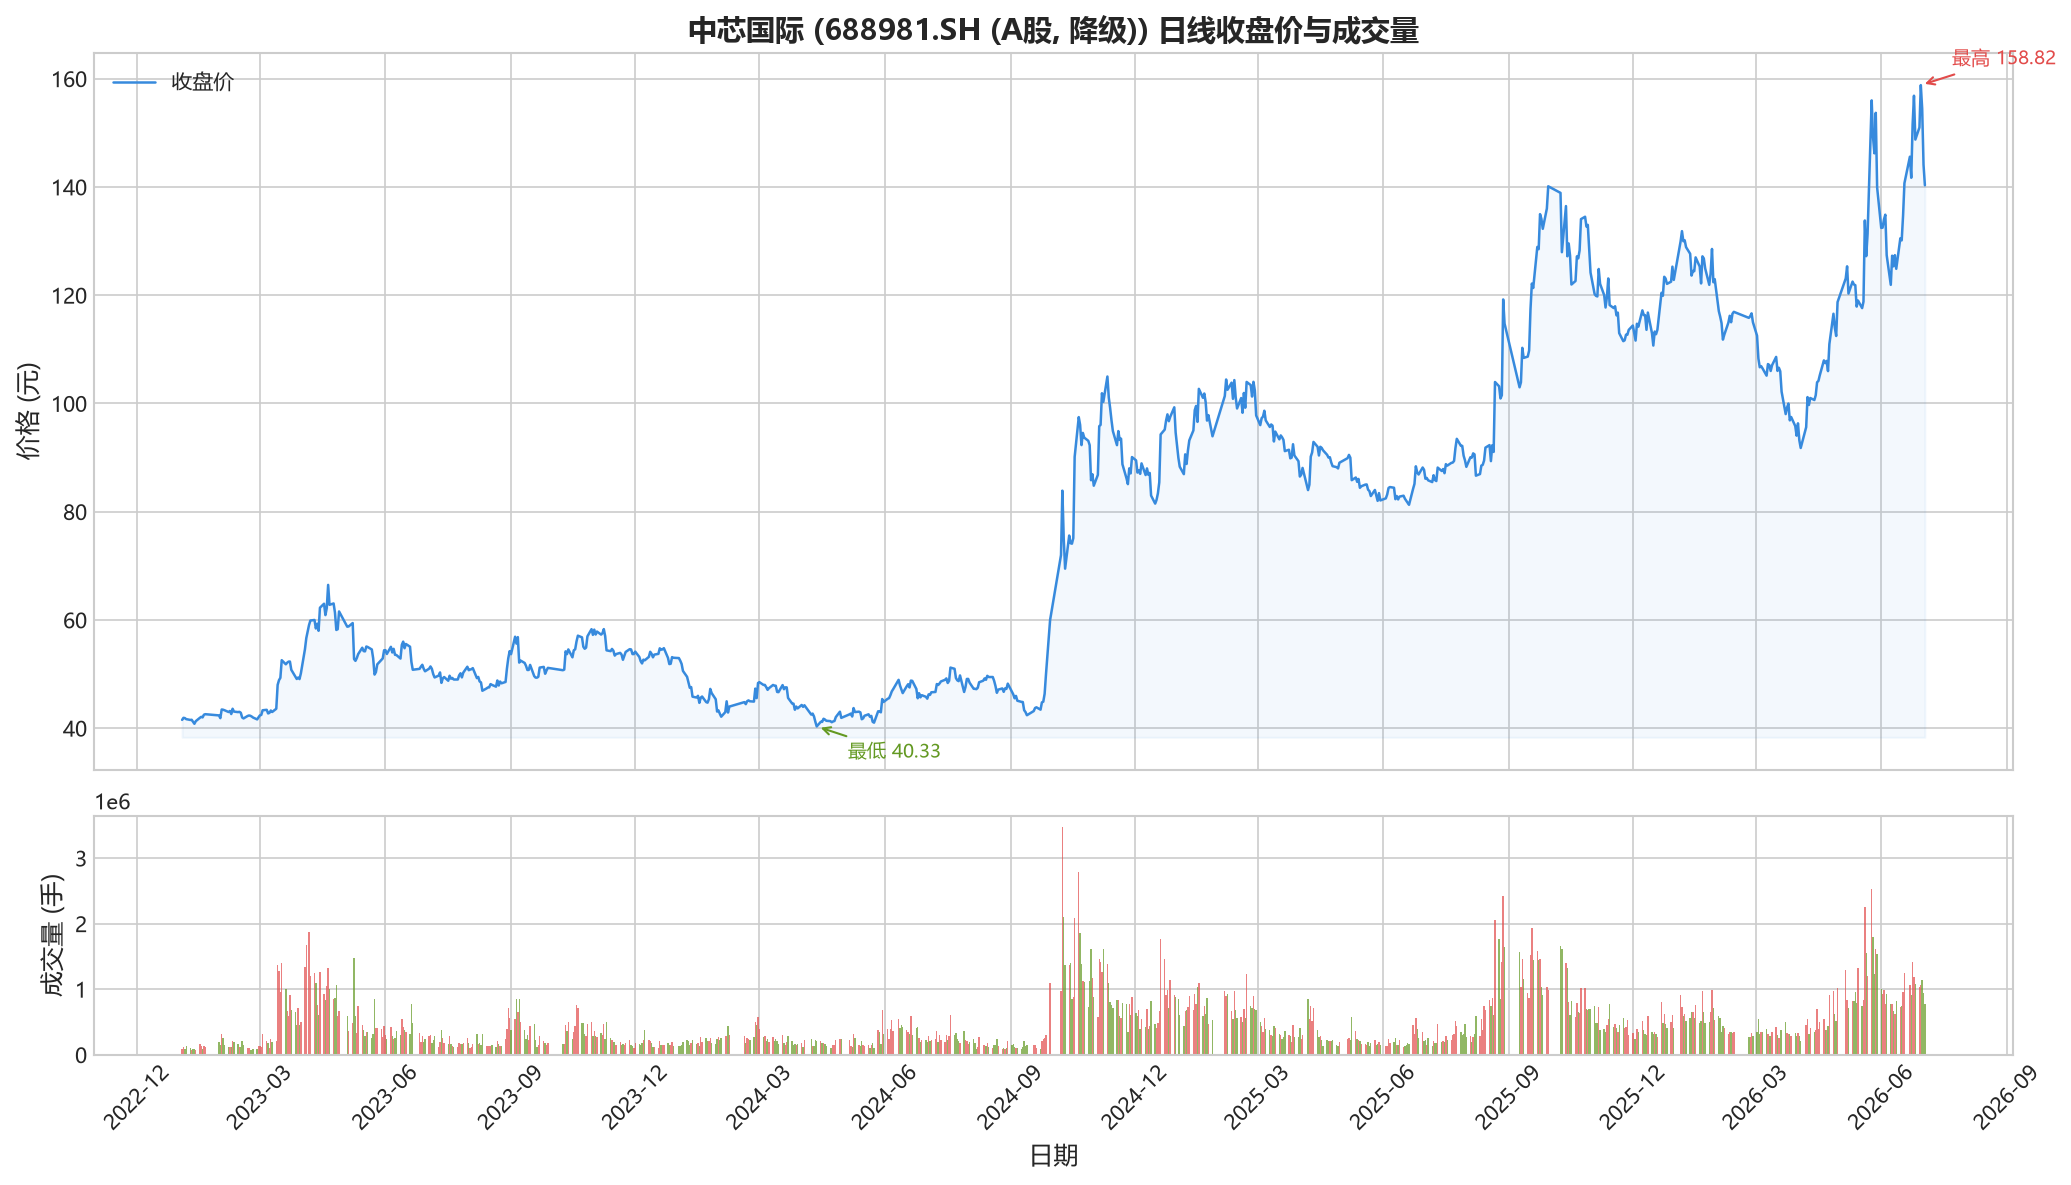

图表已保存: figures/price_volume.png


In [4]:
# === 价格走势可视化 ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# 上图: 收盘价折线
ax1.plot(df.index, df['close'], color=COLOR_PRICE, linewidth=1.2, label='收盘价')
ax1.fill_between(df.index, df['close'].min() * 0.95, df['close'], alpha=0.06, color=COLOR_PRICE)
ax1.set_title(f'中芯国际 ({DATA_SOURCE}) 日线收盘价与成交量', fontsize=14, fontweight='bold')
ax1.set_ylabel('价格 (元)', fontsize=12)
ax1.legend(loc='upper left')

# 标注最高最低点
max_idx = df['close'].idxmax()
min_idx = df['close'].idxmin()
ax1.annotate(f'最高 {df.loc[max_idx, "close"]:.2f}', xy=(max_idx, df.loc[max_idx, 'close']),
             xytext=(15, 10), textcoords='offset points', fontsize=9, color=COLOR_UP,
             arrowprops=dict(arrowstyle='->', color=COLOR_UP, lw=1))
ax1.annotate(f'最低 {df.loc[min_idx, "close"]:.2f}', xy=(min_idx, df.loc[min_idx, 'close']),
             xytext=(15, -15), textcoords='offset points', fontsize=9, color=COLOR_DOWN,
             arrowprops=dict(arrowstyle='->', color=COLOR_DOWN, lw=1))

# 下图: 成交量柱状图 (红涨绿跌)
colors_vol = [COLOR_UP if df.loc[i, 'close'] >= df.loc[i, 'pre_close'] else COLOR_DOWN for i in df.index]
ax2.bar(df.index, df['vol'], color=colors_vol, width=1, alpha=0.7)
ax2.set_ylabel('成交量 (手)', fontsize=12)
ax2.set_xlabel('日期', fontsize=12)

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'price_volume.png'), bbox_inches='tight')
plt.show()
print("图表已保存: figures/price_volume.png")

### RSI 相对强弱指数 (Relative Strength Index)

**原理**: 衡量一段时间内涨势与跌势的相对强弱，映射到 0~100 区间。

**公式 (Wilder 平滑法)**:
1. $\Delta P = Close_t - Close_{t-1}$
2. $gain = \max(\Delta P, 0)$, $loss = \max(-\Delta P, 0)$
3. $avg\_gain_t = \frac{avg\_gain_{t-1} \times 13 + gain_t}{14}$ (Wilder 平滑)
4. $RS = \frac{avg\_gain}{avg\_loss}$
5. $RSI = 100 - \frac{100}{1 + RS}$

**判读规则**:
- **RSI > 70**: 超买区，短期涨幅过大，可能回调
- **RSI < 30**: 超卖区，短期跌幅过大，可能反弹
- **RSI ≈ 50**: 多空均衡线
- **背离**: 价格创新高但 RSI 不创新高 → 顶背离(看跌)

**参数**: 14 日 (默认)

In [5]:
# === RSI 计算过程 (逐步展示中间结果) ===
period = 14

# Step 1: 价格变化
df['delta'] = df['close'].diff()

# Step 2: 涨幅/跌幅分离
df['gain'] = df['delta'].clip(lower=0)
df['loss'] = (-df['delta'].clip(upper=0))

# Step 3: Wilder 平滑平均
# 第一个值用简单平均, 后续用 Wilder 平滑
avg_gain = df['gain'].copy()
avg_loss = df['loss'].copy()
avg_gain.iloc[:period] = np.nan
avg_loss.iloc[:period] = np.nan
avg_gain.iloc[period] = df['gain'].iloc[1:period+1].mean()
avg_loss.iloc[period] = df['loss'].iloc[1:period+1].mean()

for i in range(period + 1, len(df)):
    avg_gain.iloc[i] = (avg_gain.iloc[i-1] * (period - 1) + df['gain'].iloc[i]) / period
    avg_loss.iloc[i] = (avg_loss.iloc[i-1] * (period - 1) + df['loss'].iloc[i]) / period

df['avg_gain'] = avg_gain
df['avg_loss'] = avg_loss

# Step 4: RS
df['rs'] = df['avg_gain'] / df['avg_loss']

# Step 5: RSI
df['rsi_14'] = 100 - (100 / (1 + df['rs']))

# 特殊处理: avg_loss=0 时 RSI=100
df.loc[df['avg_loss'] == 0, 'rsi_14'] = 100

# 展示中间结果
print("=== RSI 计算中间结果 (前 20 行有效数据) ===")
display_cols = ['close', 'delta', 'gain', 'loss', 'avg_gain', 'avg_loss', 'rs', 'rsi_14']
print(df[display_cols].dropna().head(20).round(4).to_string())

print(f"\nRSI 统计:")
print(f"  均值: {df['rsi_14'].mean():.2f}")
print(f"  最新值: {df['rsi_14'].iloc[-1]:.2f}")
print(f"  超买天数(>70): {(df['rsi_14'] > 70).sum()}")
print(f"  超卖天数(<30): {(df['rsi_14'] < 30).sum()}")

=== RSI 计算中间结果 (前 20 行有效数据) ===
            close  delta  gain  loss  avg_gain  avg_loss      rs   rsi_14
trade_date                                                               
2023-01-30  42.37  -0.22  0.00  0.22    0.1629    0.1036  1.5724  61.1260
2023-01-31  41.86  -0.51  0.00  0.51    0.1512    0.1326  1.1404  53.2806
2023-02-01  43.46   1.60  1.60 -0.00    0.2547    0.1231  2.0686  67.4119
2023-02-02  43.42  -0.04  0.00  0.04    0.2365    0.1172  2.0182  66.8674
2023-02-03  43.33  -0.09  0.00  0.09    0.2196    0.1153  1.9056  65.5837
2023-02-06  43.00  -0.33  0.00  0.33    0.2039    0.1306  1.5616  60.9625
2023-02-07  43.18   0.18  0.18 -0.00    0.2022    0.1213  1.6677  62.5141
2023-02-08  42.62  -0.56  0.00  0.56    0.1878    0.1526  1.2305  55.1677
2023-02-09  43.60   0.98  0.98 -0.00    0.2444    0.1417  1.7245  63.2965
2023-02-10  43.07  -0.53  0.00  0.53    0.2269    0.1694  1.3392  57.2507
2023-02-13  42.98  -0.09  0.00  0.09    0.2107    0.1638  1.2866  56.2679
2023-0

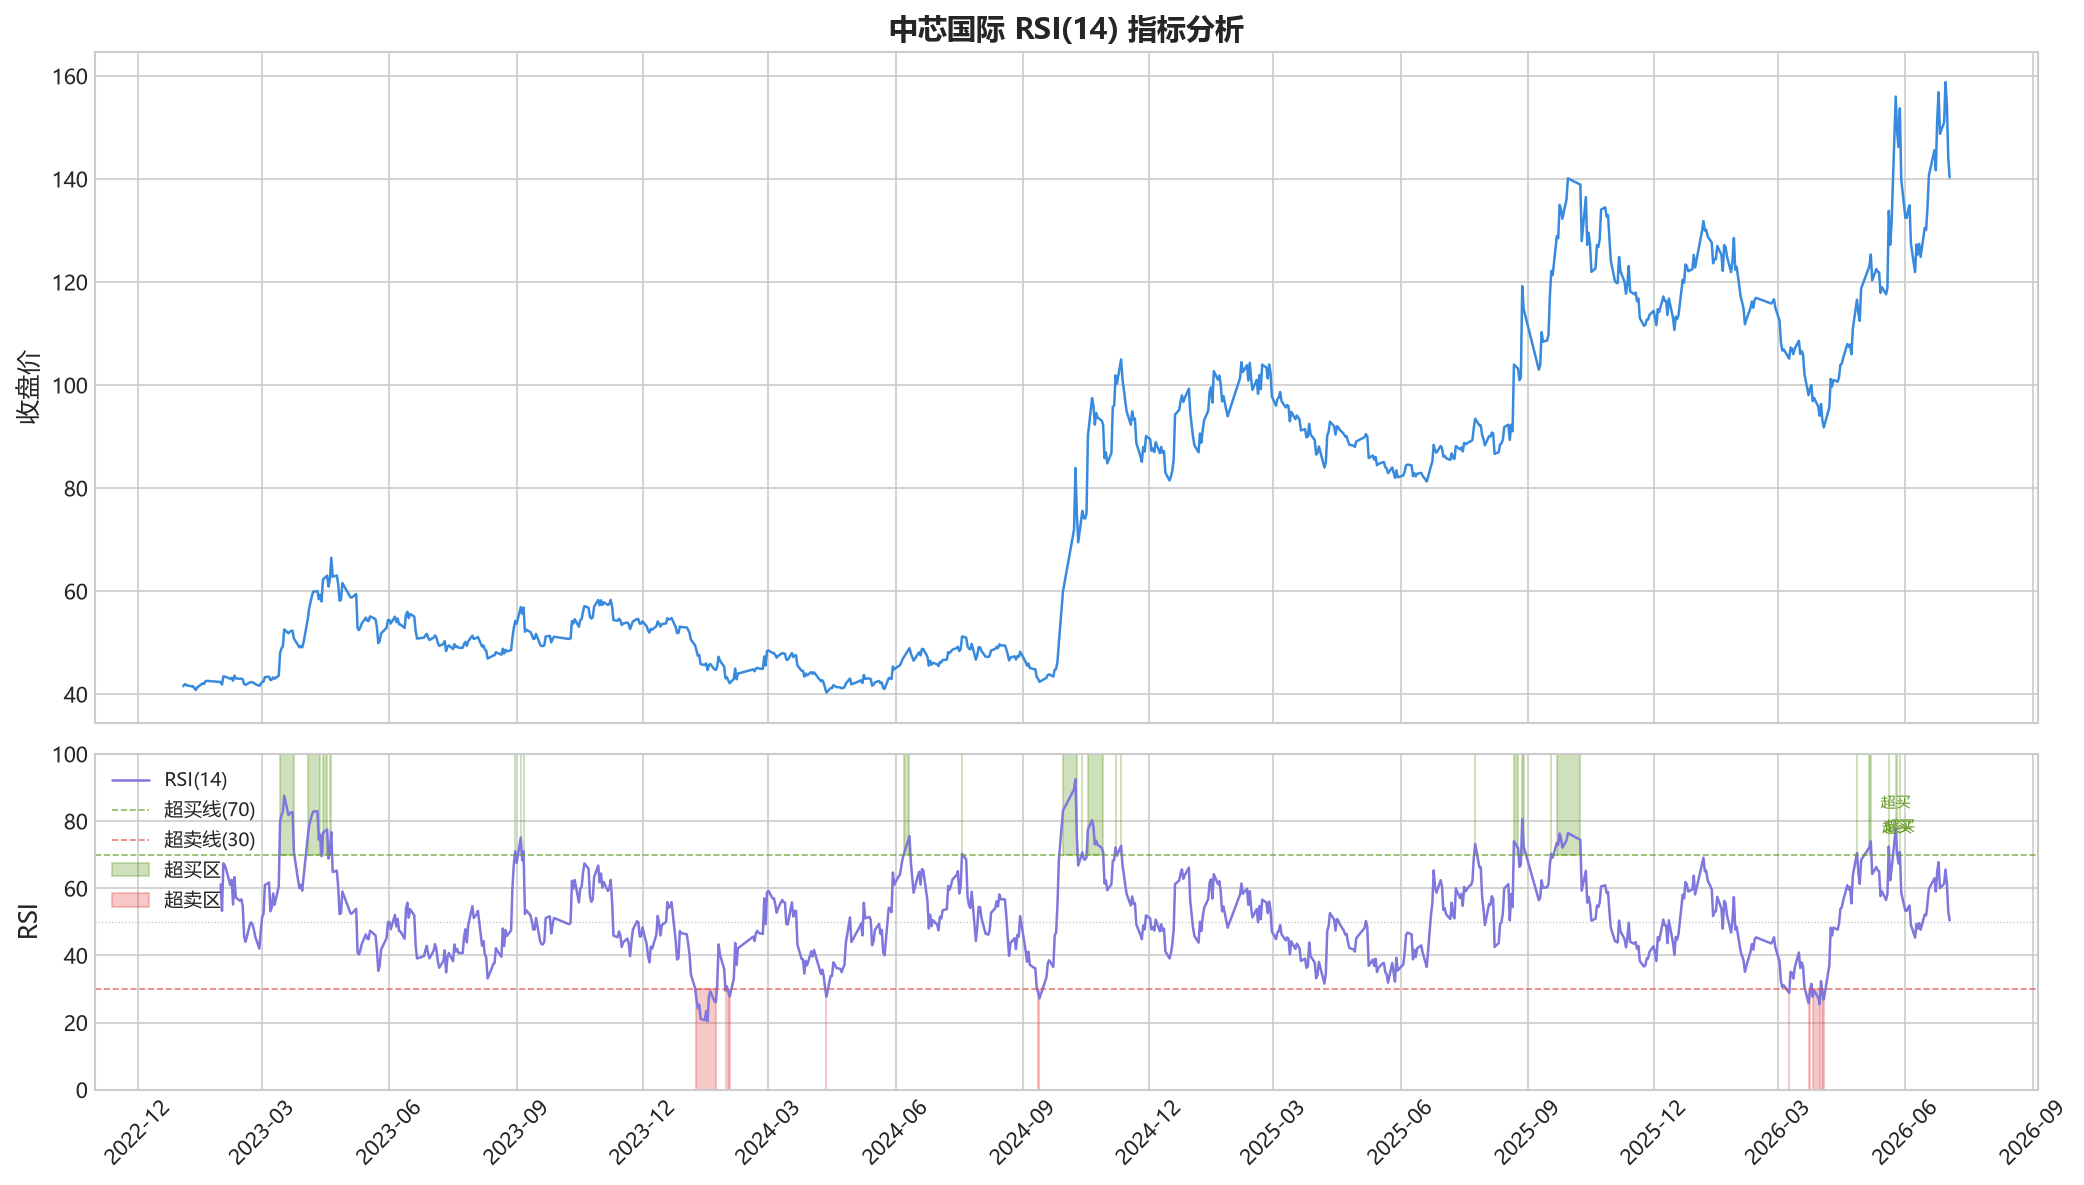

图表已保存: figures/rsi.png


In [6]:
# === RSI 可视化 ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# 上图: 收盘价
ax1.plot(df.index, df['close'], color=COLOR_PRICE, linewidth=1.2)
ax1.set_ylabel('收盘价', fontsize=12)
ax1.set_title(f'中芯国际 RSI(14) 指标分析', fontsize=14, fontweight='bold')

# 下图: RSI
ax2.plot(df.index, df['rsi_14'], color=COLOR_SIGNAL, linewidth=1.2, label='RSI(14)')
ax2.axhline(y=70, color=COLOR_DOWN, linestyle='--', linewidth=0.8, alpha=0.7, label='超买线(70)')
ax2.axhline(y=30, color=COLOR_UP, linestyle='--', linewidth=0.8, alpha=0.7, label='超卖线(30)')
ax2.axhline(y=50, color='gray', linestyle=':', linewidth=0.6, alpha=0.5)

# 填充超买/超卖区域
ax2.fill_between(df.index, 70, 100, where=df['rsi_14'] > 70, alpha=0.3, color=COLOR_DOWN, label='超买区')
ax2.fill_between(df.index, 0, 30, where=df['rsi_14'] < 30, alpha=0.3, color=COLOR_UP, label='超卖区')
ax2.set_ylim(0, 100)
ax2.set_ylabel('RSI', fontsize=12)
ax2.legend(loc='upper left', fontsize=9)

# 标注最近的超买/超卖
recent_rsi = df['rsi_14'].iloc[-60:]
ob_dates = recent_rsi[recent_rsi > 70].index
os_dates = recent_rsi[recent_rsi < 30].index
for d in ob_dates[-3:]:
    ax2.annotate('超买', xy=(d, df.loc[d, 'rsi_14']), xytext=(0, 10),
                textcoords='offset points', fontsize=7, color=COLOR_DOWN, ha='center')
for d in os_dates[-3:]:
    ax2.annotate('超卖', xy=(d, df.loc[d, 'rsi_14']), xytext=(0, -15),
                textcoords='offset points', fontsize=7, color=COLOR_UP, ha='center')

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rsi.png'), bbox_inches='tight')
plt.show()
print("图表已保存: figures/rsi.png")

### MACD 指数平滑异同移动平均线

**原理**: 通过两条不同周期的 EMA 的聚散关系，捕捉趋势方向与动能变化。

**公式**:
1. $EMA_{12} = Close$ 的 12 日指数移动平均 (快线)
2. $EMA_{26} = Close$ 的 26 日指数移动平均 (慢线)
3. $DIF = EMA_{12} - EMA_{26}$ (离差值)
4. $DEA = DIF$ 的 9 日 EMA (信号线)
5. $MACD_{柱} = (DIF - DEA) \times 2$

**判读规则**:
- **金叉**: DIF 上穿 DEA → 买入信号
- **死叉**: DIF 下穿 DEA → 卖出信号
- **零轴穿越**: DIF 上穿 0 → 多头确立; 下穿 0 → 空头确立
- **柱状图收缩**: 动能衰减，可能出现转折
- **背离**: 价格新高但 MACD 不创新高 → 顶背离

**参数**: 12 / 26 / 9 (经典参数)

In [7]:
# === MACD 计算过程 (逐步展示中间结果) ===
fast, slow, signal = 12, 26, 9

# Step 1: EMA(12) 与 EMA(26)
df['ema_12'] = df['close'].ewm(span=fast, adjust=False).mean()
df['ema_26'] = df['close'].ewm(span=slow, adjust=False).mean()

# Step 2: DIF
df['dif'] = df['ema_12'] - df['ema_26']

# Step 3: DEA (DIF 的 9 日 EMA)
df['dea'] = df['dif'].ewm(span=signal, adjust=False).mean()

# Step 4: MACD 柱
df['macd_hist'] = (df['dif'] - df['dea']) * 2

# 识别金叉/死叉
df['dif_above'] = df['dif'] > df['dea']
df['cross'] = df['dif_above'].diff()
golden_cross = df[df['cross'] == True].index
death_cross = df[df['cross'] == False].index

# 展示中间结果
print("=== MACD 计算中间结果 (前 20 行有效数据, 从第26行开始) ===")
display_cols = ['close', 'ema_12', 'ema_26', 'dif', 'dea', 'macd_hist']
print(df[display_cols].iloc[25:45].round(4).to_string())

print(f"\n金叉次数: {len(golden_cross)}")
print(f"死叉次数: {len(death_cross)}")
print(f"\n最近 3 次金叉:")
for d in golden_cross[-3:]:
    print(f"  {d.strftime('%Y-%m-%d')}  DIF={df.loc[d,'dif']:.4f}  收盘={df.loc[d,'close']:.2f}")
print(f"\n最近 3 次死叉:")
for d in death_cross[-3:]:
    print(f"  {d.strftime('%Y-%m-%d')}  DIF={df.loc[d,'dif']:.4f}  收盘={df.loc[d,'close']:.2f}")

=== MACD 计算中间结果 (前 20 行有效数据, 从第26行开始) ===
            close   ema_12   ema_26     dif     dea  macd_hist
trade_date                                                    
2023-02-14  43.03  42.9004  42.5144  0.3859  0.3709     0.0300
2023-02-15  42.86  42.8942  42.5400  0.3541  0.3676    -0.0269
2023-02-16  41.98  42.7535  42.4986  0.2550  0.3450    -0.1802
2023-02-17  41.81  42.6084  42.4476  0.1608  0.3082    -0.2948
2023-02-20  42.26  42.5548  42.4337  0.1211  0.2708    -0.2993
2023-02-21  42.35  42.5233  42.4275  0.0958  0.2358    -0.2800
2023-02-22  42.30  42.4889  42.4180  0.0709  0.2028    -0.2638
2023-02-23  42.16  42.4383  42.3989  0.0394  0.1701    -0.2614
2023-02-24  41.97  42.3663  42.3671 -0.0009  0.1359    -0.2736
2023-02-27  41.63  42.2530  42.3125 -0.0595  0.0968    -0.3127
2023-02-28  42.02  42.2171  42.2909 -0.0737  0.0627    -0.2729
2023-03-01  42.37  42.2407  42.2967 -0.0561  0.0390    -0.1901
2023-03-02  42.46  42.2744  42.3088 -0.0344  0.0243    -0.1174
2023-03-03  4

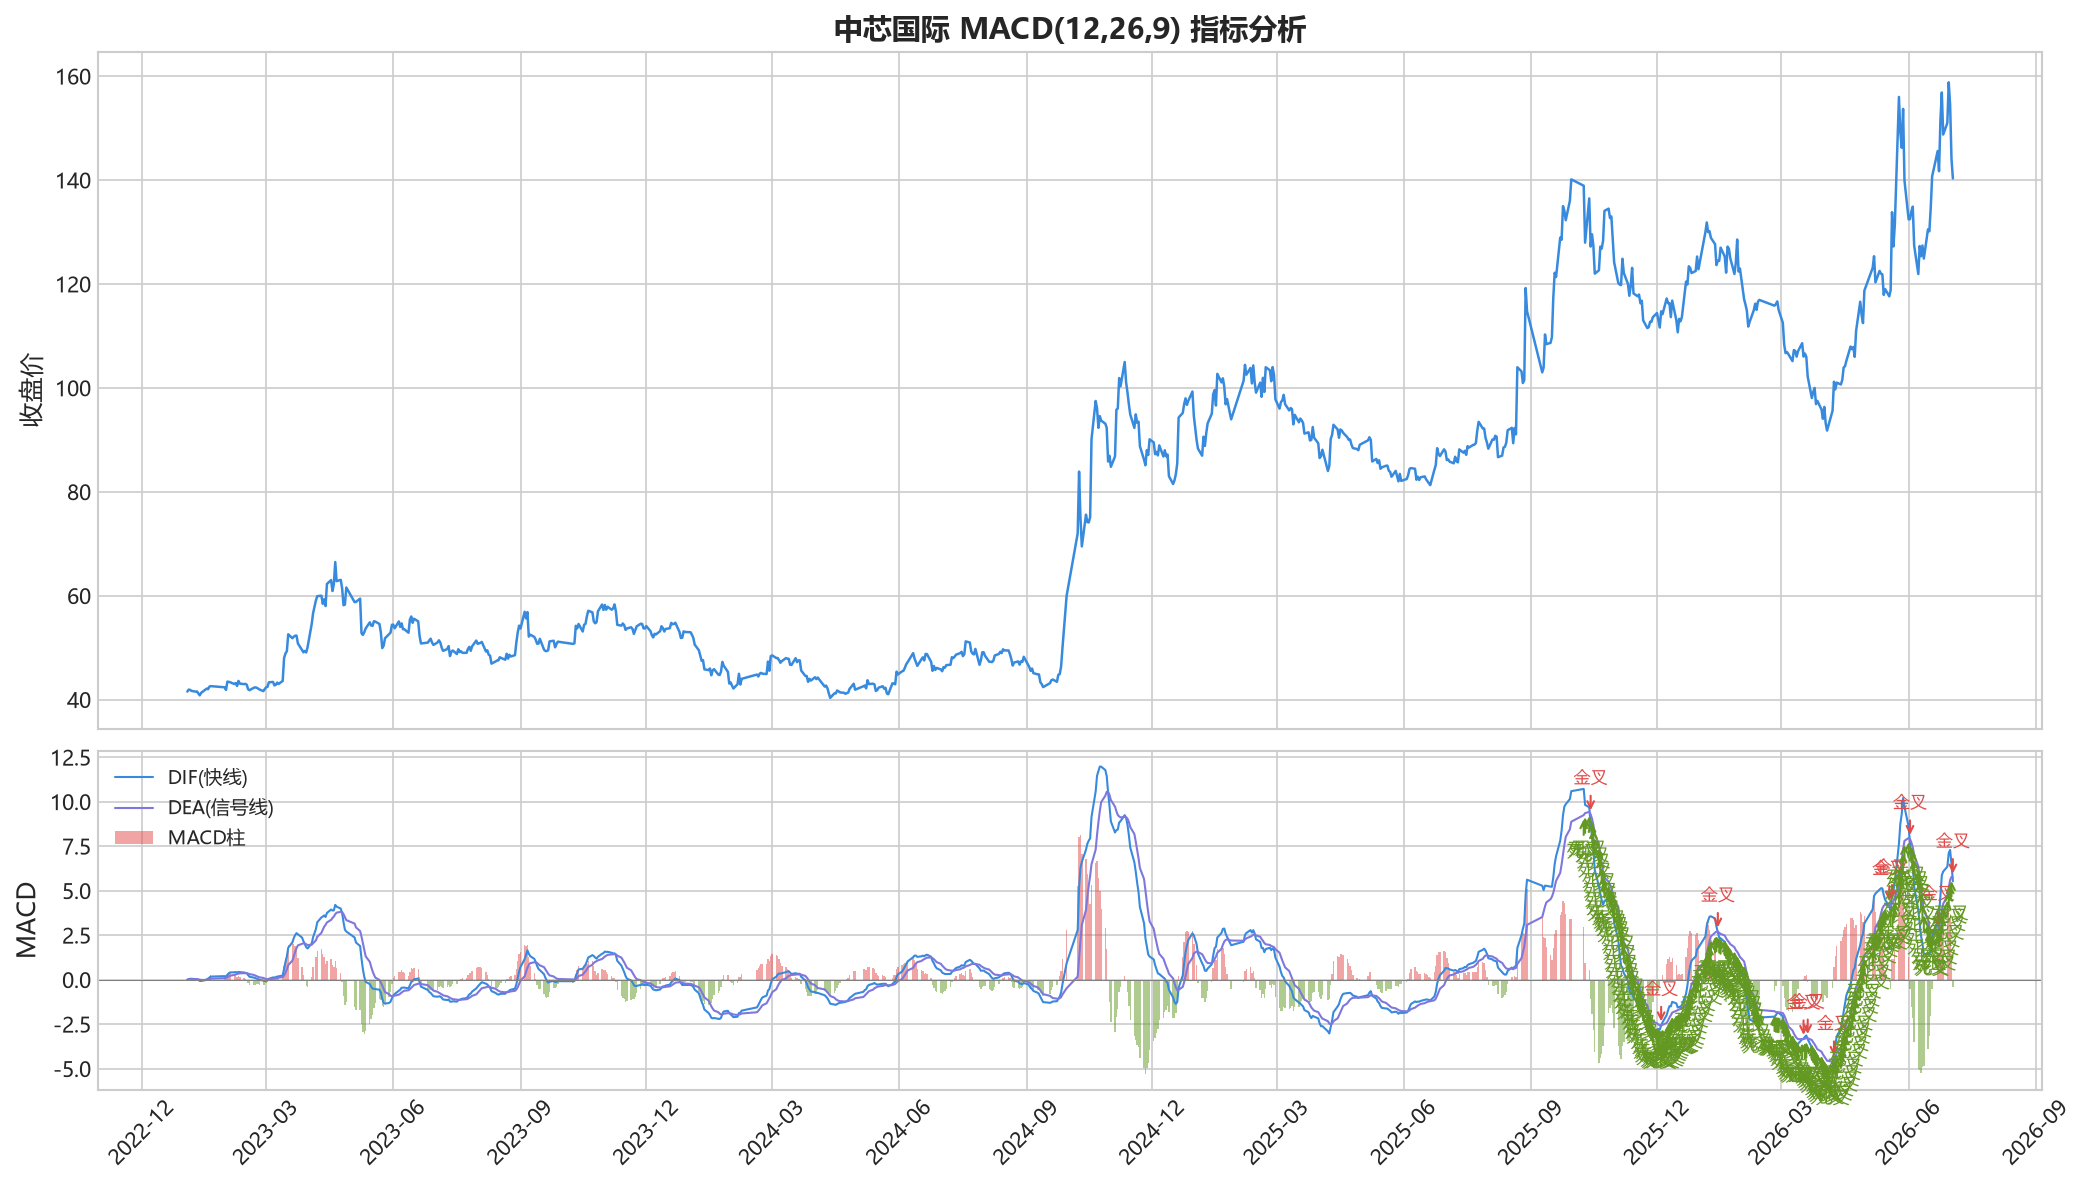

图表已保存: figures/macd.png


In [8]:
# === MACD 可视化 ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# 上图: 收盘价
ax1.plot(df.index, df['close'], color=COLOR_PRICE, linewidth=1.2)
ax1.set_ylabel('收盘价', fontsize=12)
ax1.set_title(f'中芯国际 MACD(12,26,9) 指标分析', fontsize=14, fontweight='bold')

# 下图: DIF/DEA 折线 + MACD 柱状图
macd_colors = [COLOR_UP if v >= 0 else COLOR_DOWN for v in df['macd_hist']]
ax2.bar(df.index, df['macd_hist'], color=macd_colors, width=1, alpha=0.5, label='MACD柱')
ax2.plot(df.index, df['dif'], color=COLOR_PRICE, linewidth=1, label='DIF(快线)')
ax2.plot(df.index, df['dea'], color=COLOR_SIGNAL, linewidth=1, label='DEA(信号线)')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# 标注金叉/死叉 (只标注最近 6 个月内的)
recent_golden = [d for d in golden_cross if d > df.index[-180]]
recent_death = [d for d in death_cross if d > df.index[-180]]
for d in recent_golden:
    ax2.annotate('金叉', xy=(d, df.loc[d, 'dea']), xytext=(0, 15),
                textcoords='offset points', fontsize=8, color=COLOR_UP, ha='center',
                arrowprops=dict(arrowstyle='->', color=COLOR_UP, lw=1))
for d in recent_death:
    ax2.annotate('死叉', xy=(d, df.loc[d, 'dea']), xytext=(0, -20),
                textcoords='offset points', fontsize=8, color=COLOR_DOWN, ha='center',
                arrowprops=dict(arrowstyle='->', color=COLOR_DOWN, lw=1))

ax2.set_ylabel('MACD', fontsize=12)
ax2.legend(loc='upper left', fontsize=9)

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'macd.png'), bbox_inches='tight')
plt.show()
print("图表已保存: figures/macd.png")

### 布林带 (Bollinger Bands)

**原理**: 用移动平均线 ± 2 倍标准差构建动态价格通道，同时反映趋势方向和波动率水平。

**公式**:
1. $中轨 = SMA(Close, 20)$ (20 日简单移动平均)
2. $\sigma = Std(Close, 20)$ (20 日标准差)
3. $上轨 = 中轨 + 2\sigma$
4. $下轨 = 中轨 - 2\sigma$
5. $带宽 = \frac{上轨 - 下轨}{中轨}$
6. $\%B = \frac{Close - 下轨}{上轨 - 下轨}$

**判读规则**:
- **挤压 (Squeeze)**: 带宽极度收窄 → 波动率低位，大行情前蓄势
- **扩张 (Expansion)**: 带宽急速放大 → 行情已启动
- **触上轨**: 短期偏强; **触下轨**: 短期偏弱
- **中轨支撑/阻力**: 回踩中轨获支撑 → 趋势仍在

**参数**: 20 日, 2σ (经典参数)

In [9]:
# === 布林带计算过程 (逐步展示中间结果) ===
window = 20
num_std = 2

# Step 1: 中轨 SMA(20)
df['bb_mid'] = df['close'].rolling(window=window).mean()

# Step 2: 标准差
df['bb_std'] = df['close'].rolling(window=window).std()

# Step 3: 上轨 / 下轨
df['bb_upper'] = df['bb_mid'] + num_std * df['bb_std']
df['bb_lower'] = df['bb_mid'] - num_std * df['bb_std']

# Step 4: 带宽
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['bb_mid']

# Step 5: %B
df['bb_pct_b'] = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])

# 识别挤压区间 (带宽低于近 120 日 20% 分位)
df['bb_squeeze'] = df['bb_width'] < df['bb_width'].rolling(120, min_periods=20).quantile(0.2)

# 展示中间结果
print("=== 布林带计算中间结果 (前 20 行有效数据) ===")
display_cols = ['close', 'bb_mid', 'bb_std', 'bb_upper', 'bb_lower', 'bb_width', 'bb_pct_b']
print(df[display_cols].dropna().head(20).round(4).to_string())

print(f"\n布林带统计:")
print(f"  当前带宽: {df['bb_width'].iloc[-1]:.4f}")
print(f"  带宽 120日均值: {df['bb_width'].tail(120).mean():.4f}")
print(f"  当前 %B: {df['bb_pct_b'].iloc[-1]:.4f}")
print(f"  挤压天数: {df['bb_squeeze'].sum()}")

=== 布林带计算中间结果 (前 20 行有效数据) ===
            close   bb_mid  bb_std  bb_upper  bb_lower  bb_width  bb_pct_b
trade_date                                                                
2023-02-06  43.00  42.0975  0.7541   43.6057   40.5893    0.0717    0.7992
2023-02-07  43.18  42.1795  0.7790   43.7376   40.6214    0.0739    0.8211
2023-02-08  42.62  42.2145  0.7825   43.7795   40.6495    0.0741    0.6296
2023-02-09  43.60  42.3010  0.8362   43.9733   40.6287    0.0791    0.8884
2023-02-10  43.07  42.3705  0.8396   44.0497   40.6913    0.0793    0.7083
2023-02-13  42.98  42.4430  0.8257   44.0944   40.7916    0.0778    0.6626
2023-02-14  43.03  42.5165  0.8082   44.1329   40.9001    0.0760    0.6588
2023-02-15  42.86  42.6005  0.7470   44.0944   41.1066    0.0701    0.5869
2023-02-16  41.98  42.6585  0.6386   43.9357   41.3813    0.0599    0.2344
2023-02-17  41.81  42.6840  0.5898   43.8636   41.5044    0.0553    0.1295
2023-02-20  42.26  42.7010  0.5712   43.8435   41.5585    0.0535    0

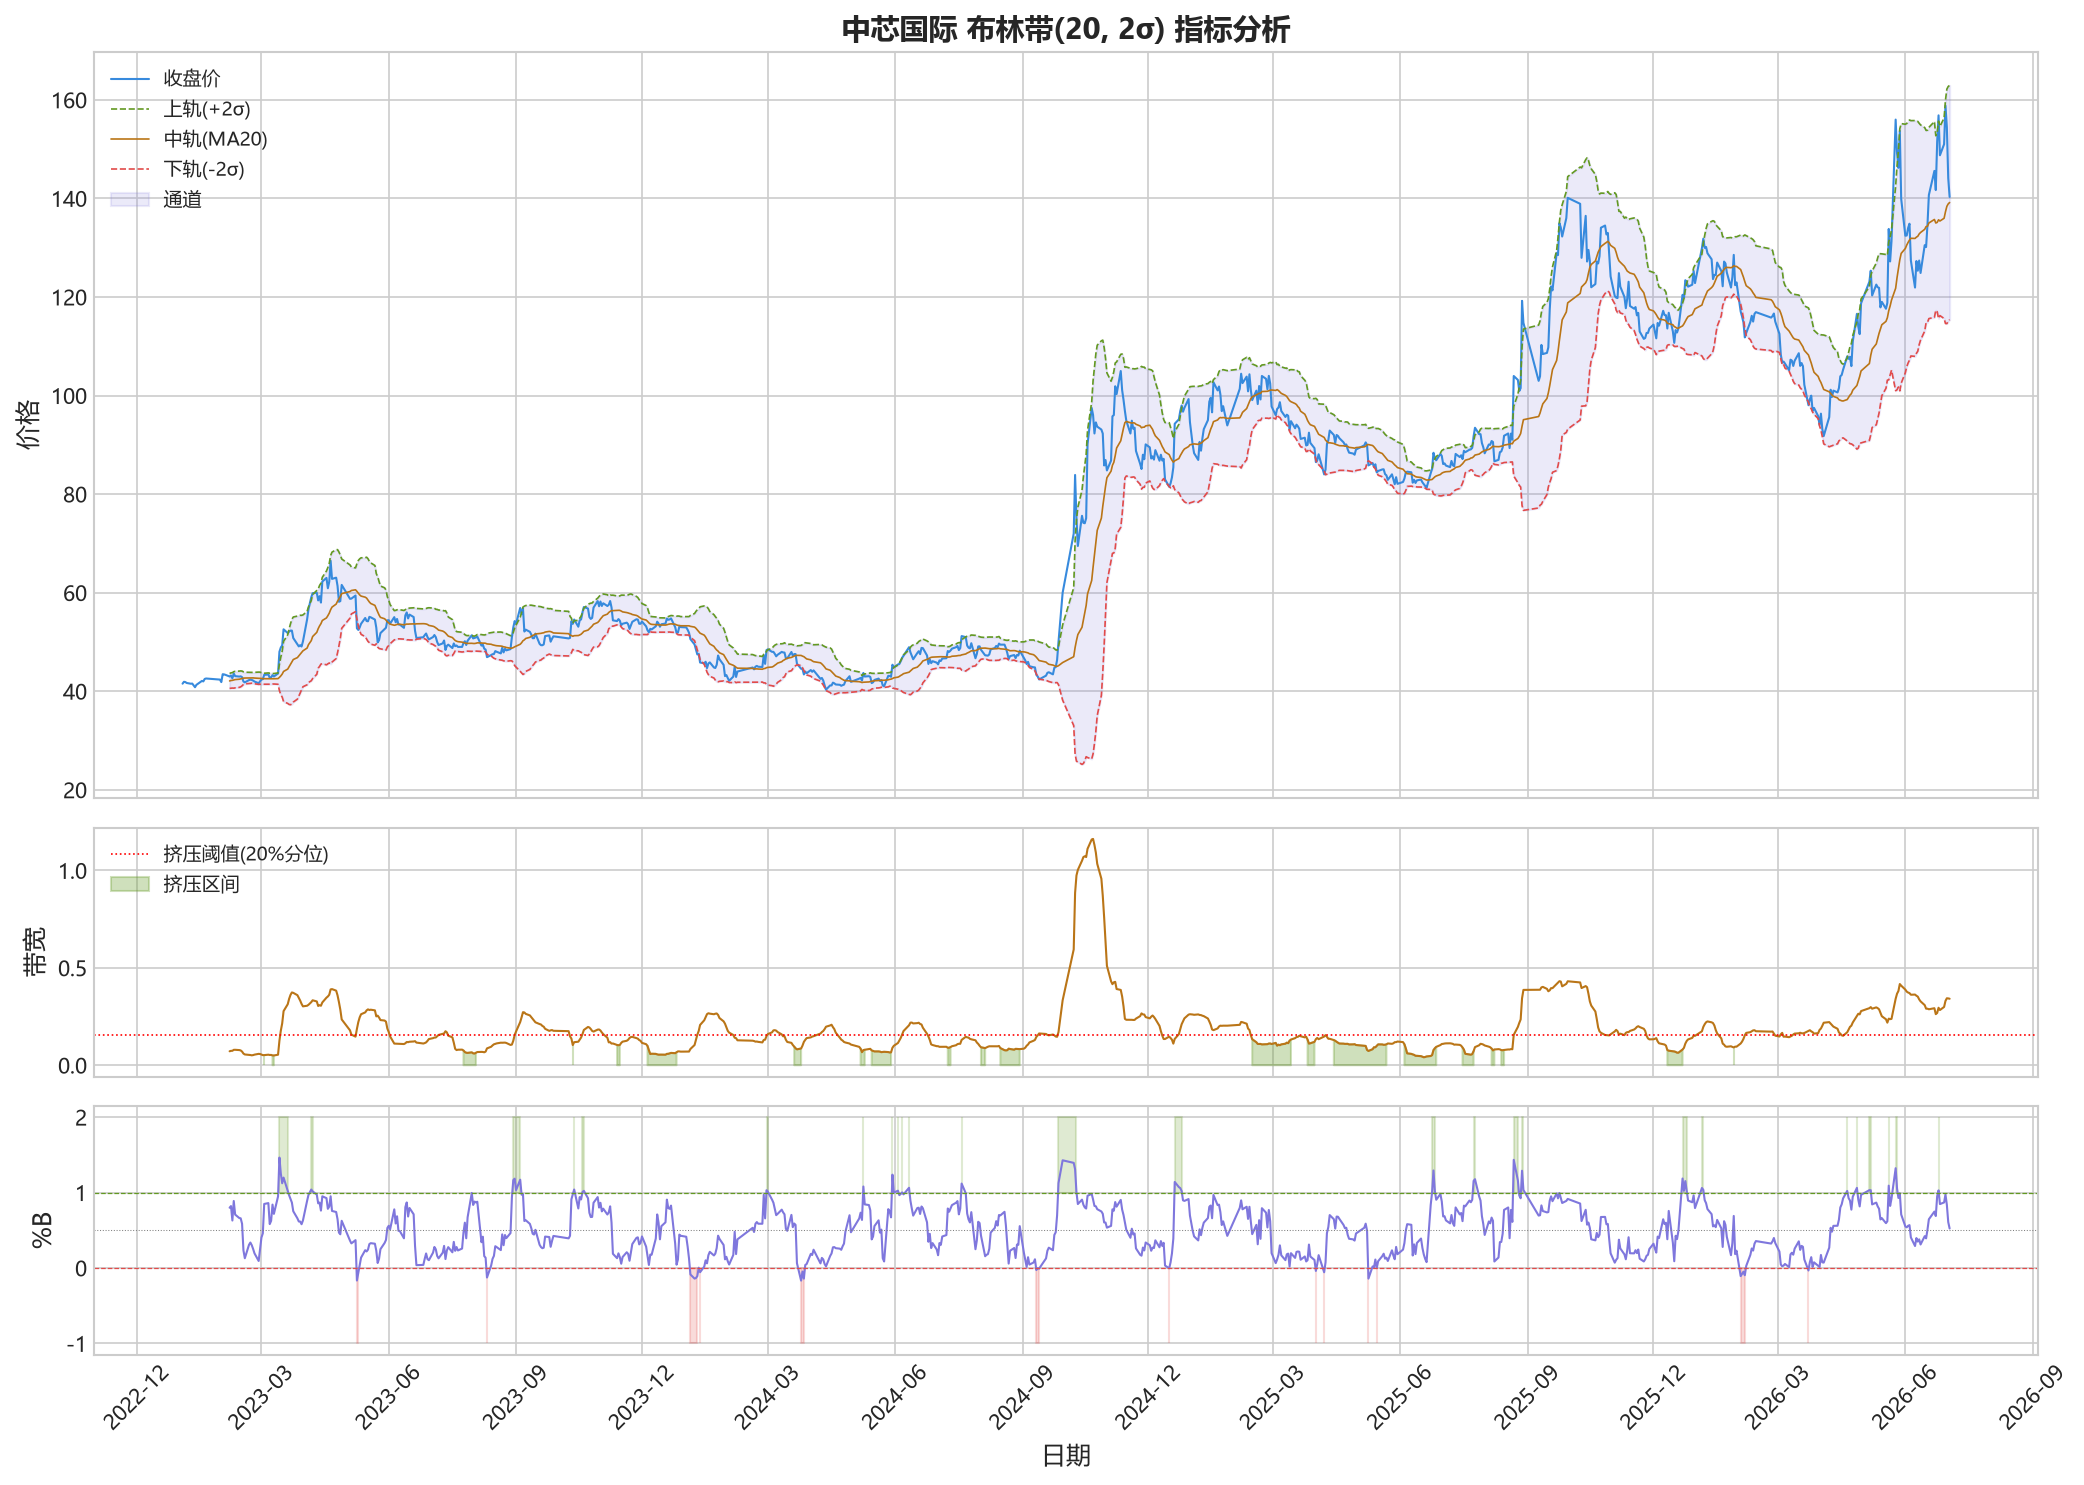

图表已保存: figures/bollinger.png


In [10]:
# === 布林带可视化 (三面板) ===
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10),
                                     gridspec_kw={'height_ratios': [3, 1, 1]}, sharex=True)

# 上图: 价格 + 布林带通道
ax1.plot(df.index, df['close'], color=COLOR_PRICE, linewidth=1, label='收盘价')
ax1.plot(df.index, df['bb_upper'], color=COLOR_DOWN, linewidth=0.8, linestyle='--', label='上轨(+2σ)')
ax1.plot(df.index, df['bb_mid'], color=COLOR_ACCENT, linewidth=0.8, linestyle='-', label='中轨(MA20)')
ax1.plot(df.index, df['bb_lower'], color=COLOR_UP, linewidth=0.8, linestyle='--', label='下轨(-2σ)')
ax1.fill_between(df.index, df['bb_lower'], df['bb_upper'], alpha=FILL_ALPHA, color=COLOR_SIGNAL, label='通道')
ax1.set_ylabel('价格', fontsize=12)
ax1.set_title(f'中芯国际 布林带(20, 2σ) 指标分析', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)

# 中图: 带宽
ax2.plot(df.index, df['bb_width'], color=COLOR_ACCENT, linewidth=1)
ax2.axhline(y=df['bb_width'].tail(120).quantile(0.2), color='red', linestyle=':', linewidth=0.8, label='挤压阈值(20%分位)')
# 标注挤压区间
squeeze = df['bb_squeeze']
if squeeze.any():
    ax2.fill_between(df.index, 0, df['bb_width'], where=squeeze, alpha=0.3, color=COLOR_DOWN, label='挤压区间')
ax2.set_ylabel('带宽', fontsize=12)
ax2.legend(loc='upper left', fontsize=9)

# 下图: %B
ax3.plot(df.index, df['bb_pct_b'], color=COLOR_SIGNAL, linewidth=1)
ax3.axhline(y=1.0, color=COLOR_DOWN, linestyle='--', linewidth=0.6)
ax3.axhline(y=0.5, color='gray', linestyle=':', linewidth=0.5)
ax3.axhline(y=0.0, color=COLOR_UP, linestyle='--', linewidth=0.6)
ax3.fill_between(df.index, 1.0, 2, where=df['bb_pct_b'] > 1, alpha=0.2, color=COLOR_DOWN)
ax3.fill_between(df.index, -1, 0.0, where=df['bb_pct_b'] < 0, alpha=0.2, color=COLOR_UP)
ax3.set_ylabel('%B', fontsize=12)
ax3.set_xlabel('日期', fontsize=12)

ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'bollinger.png'), bbox_inches='tight')
plt.show()
print("图表已保存: figures/bollinger.png")

### ATR 平均真实波幅 (Average True Range)

**原理**: 衡量价格的波动幅度（不指示方向），用于设定止损、管理仓位和过滤趋势。

**公式**:
1. $TR = \max(High - Low,\ |High - PrevClose|,\ |Low - PrevClose|)$
   - 正常波动: 当日最高 − 当日最低
   - 跳空高开: 当日最高 − 昨日收盘
   - 跳空低开: 昨日收盘 − 当日最低
2. $ATR = Wilder$ 平滑 (首日用 SMA, 后续 $ATR_t = \frac{ATR_{t-1} \times 13 + TR_t}{14}$)

**应用**:
- **动态止损**: 止损价 = 入场价 − 2×ATR (多头)
- **仓位管理**: 仓位 = 风险金额 / (ATR × 倍数)
- **ATR 飙升**: 波动加剧，可能趋势转折
- **ATR 低迷**: 市场平静，盘整蓄势

**参数**: 14 日 (默认)

> **对中芯国际的意义**: 半导体股常出现跳空缺口，ATR 能把缺口纳入波动衡量，
> 比单纯用日内振幅更准确。

In [11]:
# === ATR 计算过程 (逐步展示中间结果) ===
period = 14

# Step 1: TR (True Range)
df['prev_close'] = df['close'].shift(1)
df['tr_hl'] = df['high'] - df['low']
df['tr_hpc'] = (df['high'] - df['prev_close']).abs()
df['tr_lpc'] = (df['low'] - df['prev_close']).abs()
df['tr'] = df[['tr_hl', 'tr_hpc', 'tr_lpc']].max(axis=1)

# Step 2: ATR (Wilder 平滑法)
atr = df['tr'].copy()
atr.iloc[:period] = np.nan
atr.iloc[period] = df['tr'].iloc[1:period+1].mean()
for i in range(period + 1, len(df)):
    atr.iloc[i] = (atr.iloc[i-1] * (period - 1) + df['tr'].iloc[i]) / period
df['atr_14'] = atr

# Step 3: 动态止损线 (基于最近入场价 - 2*ATR)
df['stop_loss_2atr'] = df['close'] - 2 * df['atr_14']

# 展示中间结果
print("=== ATR 计算中间结果 (前 20 行有效数据) ===")
display_cols = ['high', 'low', 'close', 'prev_close', 'tr_hl', 'tr_hpc', 'tr_lpc', 'tr', 'atr_14']
print(df[display_cols].dropna().head(20).round(4).to_string())

print(f"\nATR 统计:")
print(f"  均值: {df['atr_14'].mean():.4f}")
print(f"  最新值: {df['atr_14'].iloc[-1]:.4f}")
print(f"  最大值: {df['atr_14'].max():.4f}")
print(f"  最小值: {df['atr_14'].min():.4f}")
print(f"  最新止损价 (2×ATR): {df['stop_loss_2atr'].iloc[-1]:.2f}")

=== ATR 计算中间结果 (前 20 行有效数据) ===
             high    low  close  prev_close  tr_hl  tr_hpc  tr_lpc    tr  atr_14
trade_date                                                                      
2023-01-30  43.08  42.37  42.37       42.59   0.71    0.49    0.22  0.71  0.5464
2023-01-31  42.60  41.67  41.86       42.37   0.93    0.23    0.70  0.93  0.5738
2023-02-01  43.55  41.96  43.46       41.86   1.59    1.69    0.10  1.69  0.6536
2023-02-02  43.95  43.16  43.42       43.46   0.79    0.49    0.30  0.79  0.6633
2023-02-03  43.62  42.81  43.33       43.42   0.81    0.20    0.61  0.81  0.6738
2023-02-06  43.26  42.75  43.00       43.33   0.51    0.07    0.58  0.58  0.6671
2023-02-07  43.18  42.91  43.18       43.00   0.27    0.18    0.09  0.27  0.6387
2023-02-08  43.40  42.62  42.62       43.18   0.78    0.22    0.56  0.78  0.6488
2023-02-09  43.60  42.45  43.60       42.62   1.15    0.98    0.17  1.15  0.6846
2023-02-10  43.64  42.86  43.07       43.60   0.78    0.04    0.74  0.78  0.6

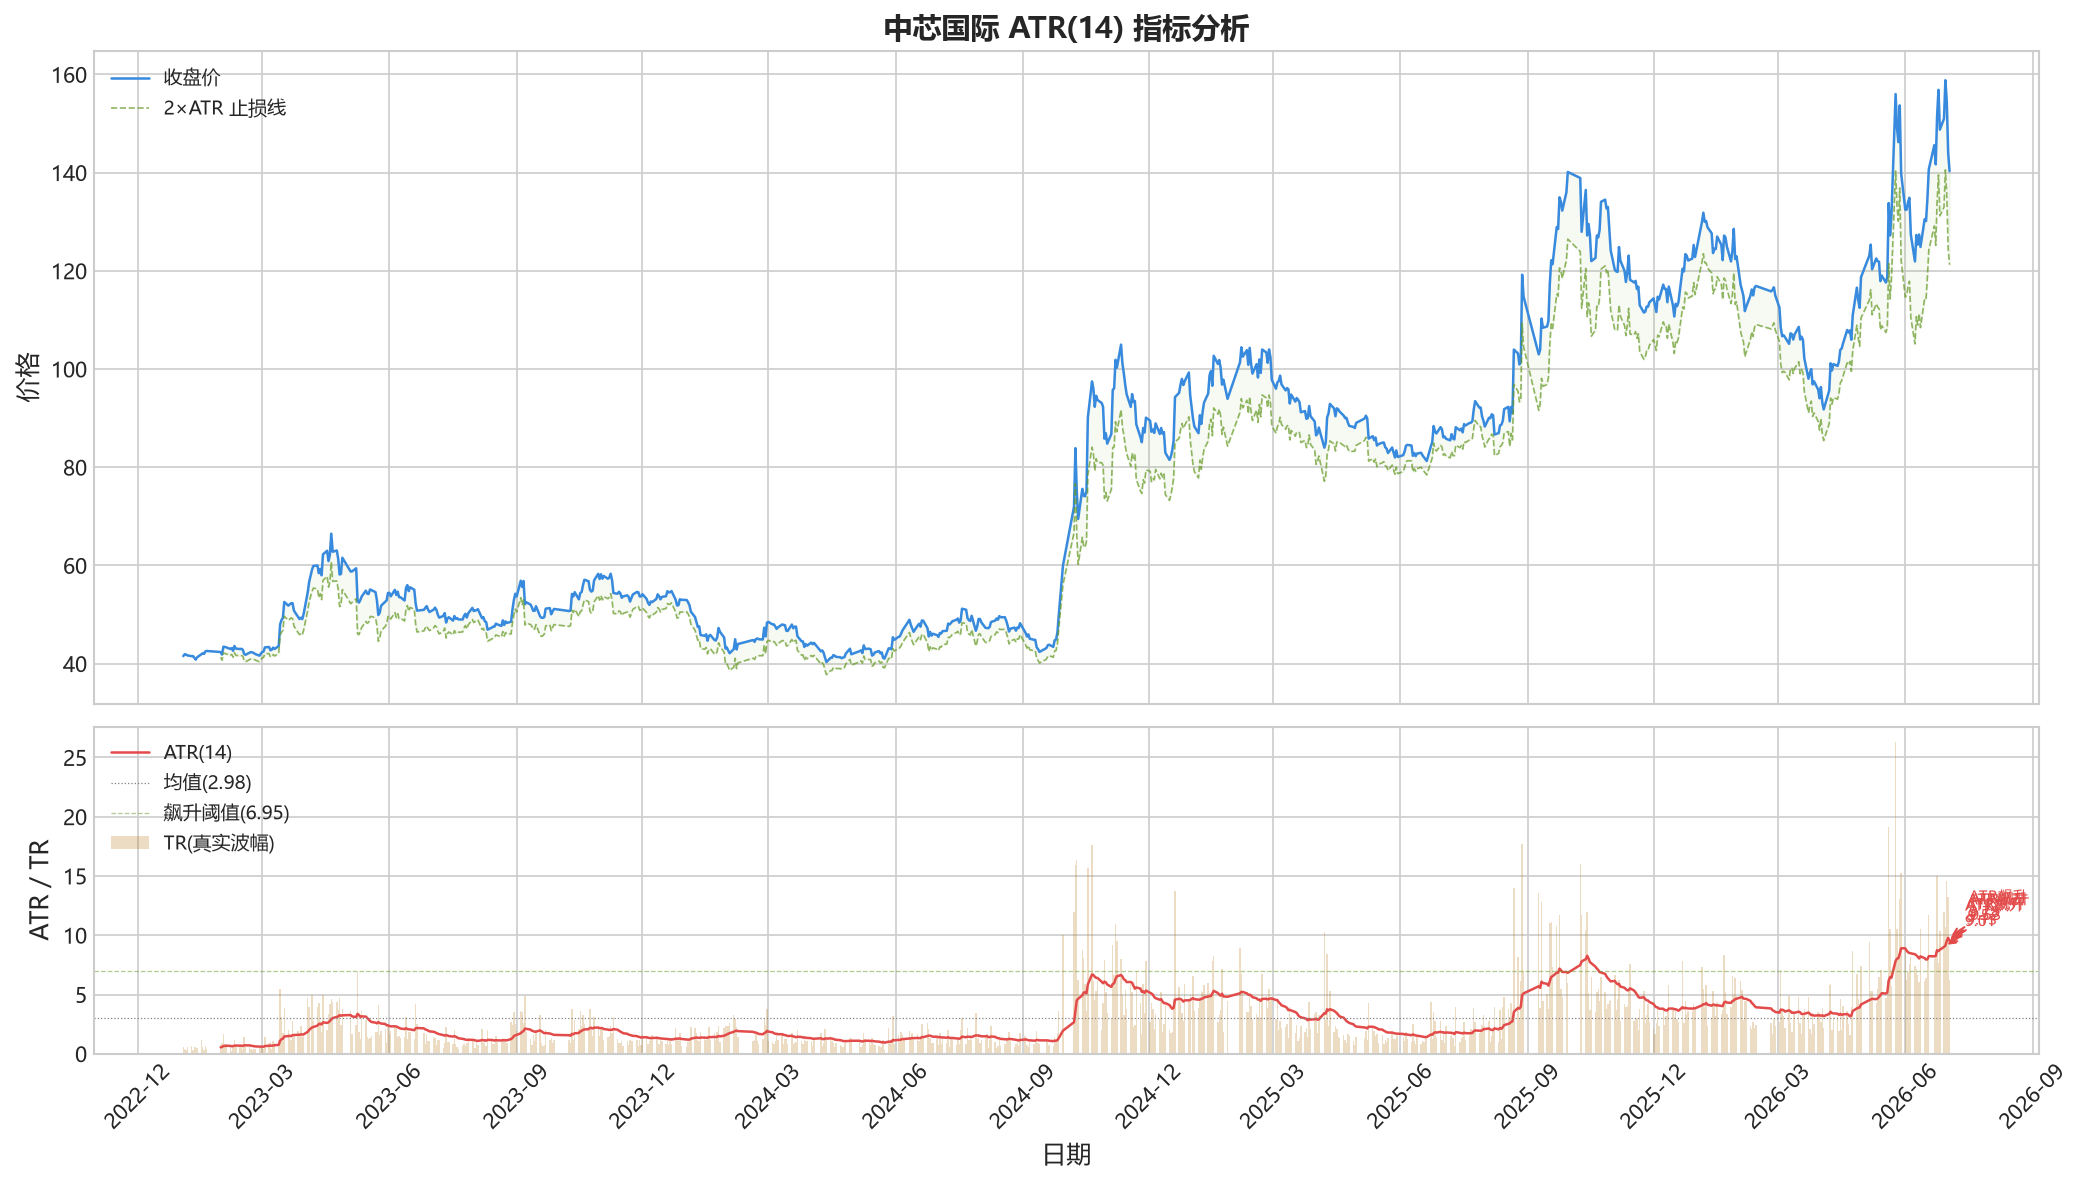

图表已保存: figures/atr.png


In [12]:
# === ATR 可视化 ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# 上图: 收盘价 + 止损线
ax1.plot(df.index, df['close'], color=COLOR_PRICE, linewidth=1.2, label='收盘价')
ax1.plot(df.index, df['stop_loss_2atr'], color=COLOR_DOWN, linewidth=0.8, linestyle='--', alpha=0.7, label='2×ATR 止损线')
ax1.fill_between(df.index, df['stop_loss_2atr'], df['close'], alpha=0.05, color=COLOR_DOWN)
ax1.set_ylabel('价格', fontsize=12)
ax1.set_title(f'中芯国际 ATR(14) 指标分析', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)

# 下图: ATR 折线 + TR 柱状图
ax2.bar(df.index, df['tr'], color=COLOR_ACCENT, width=1, alpha=0.25, label='TR(真实波幅)')
ax2.plot(df.index, df['atr_14'], color=COLOR_UP, linewidth=1.2, label='ATR(14)')

# 标注 ATR 飙升 (ATR > 均值 + 2σ)
atr_mean = df['atr_14'].mean()
atr_std = df['atr_14'].std()
spike_threshold = atr_mean + 2 * atr_std
spikes = df[df['atr_14'] > spike_threshold].index
recent_spikes = [d for d in spikes if d > df.index[-180]]
for d in recent_spikes[-5:]:
    ax2.annotate(f'ATR飙升\n{df.loc[d,"atr_14"]:.2f}', xy=(d, df.loc[d, 'atr_14']),
                xytext=(10, 10), textcoords='offset points', fontsize=7, color=COLOR_UP,
                arrowprops=dict(arrowstyle='->', color=COLOR_UP, lw=1))

ax2.axhline(y=atr_mean, color='gray', linestyle=':', linewidth=0.6, label=f'均值({atr_mean:.2f})')
ax2.axhline(y=spike_threshold, color=COLOR_DOWN, linestyle='--', linewidth=0.6, alpha=0.5, label=f'飙升阈值({spike_threshold:.2f})')
ax2.set_ylabel('ATR / TR', fontsize=12)
ax2.set_xlabel('日期', fontsize=12)
ax2.legend(loc='upper left', fontsize=9)

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'atr.png'), bbox_inches='tight')
plt.show()
print("图表已保存: figures/atr.png")

### 四指标综合仪表盘

将 RSI、MACD、布林带、ATR 四项指标的关键信号汇总为一张 2×2 面板，
共享 X 轴(日期)，便于交叉验证与综合判断。

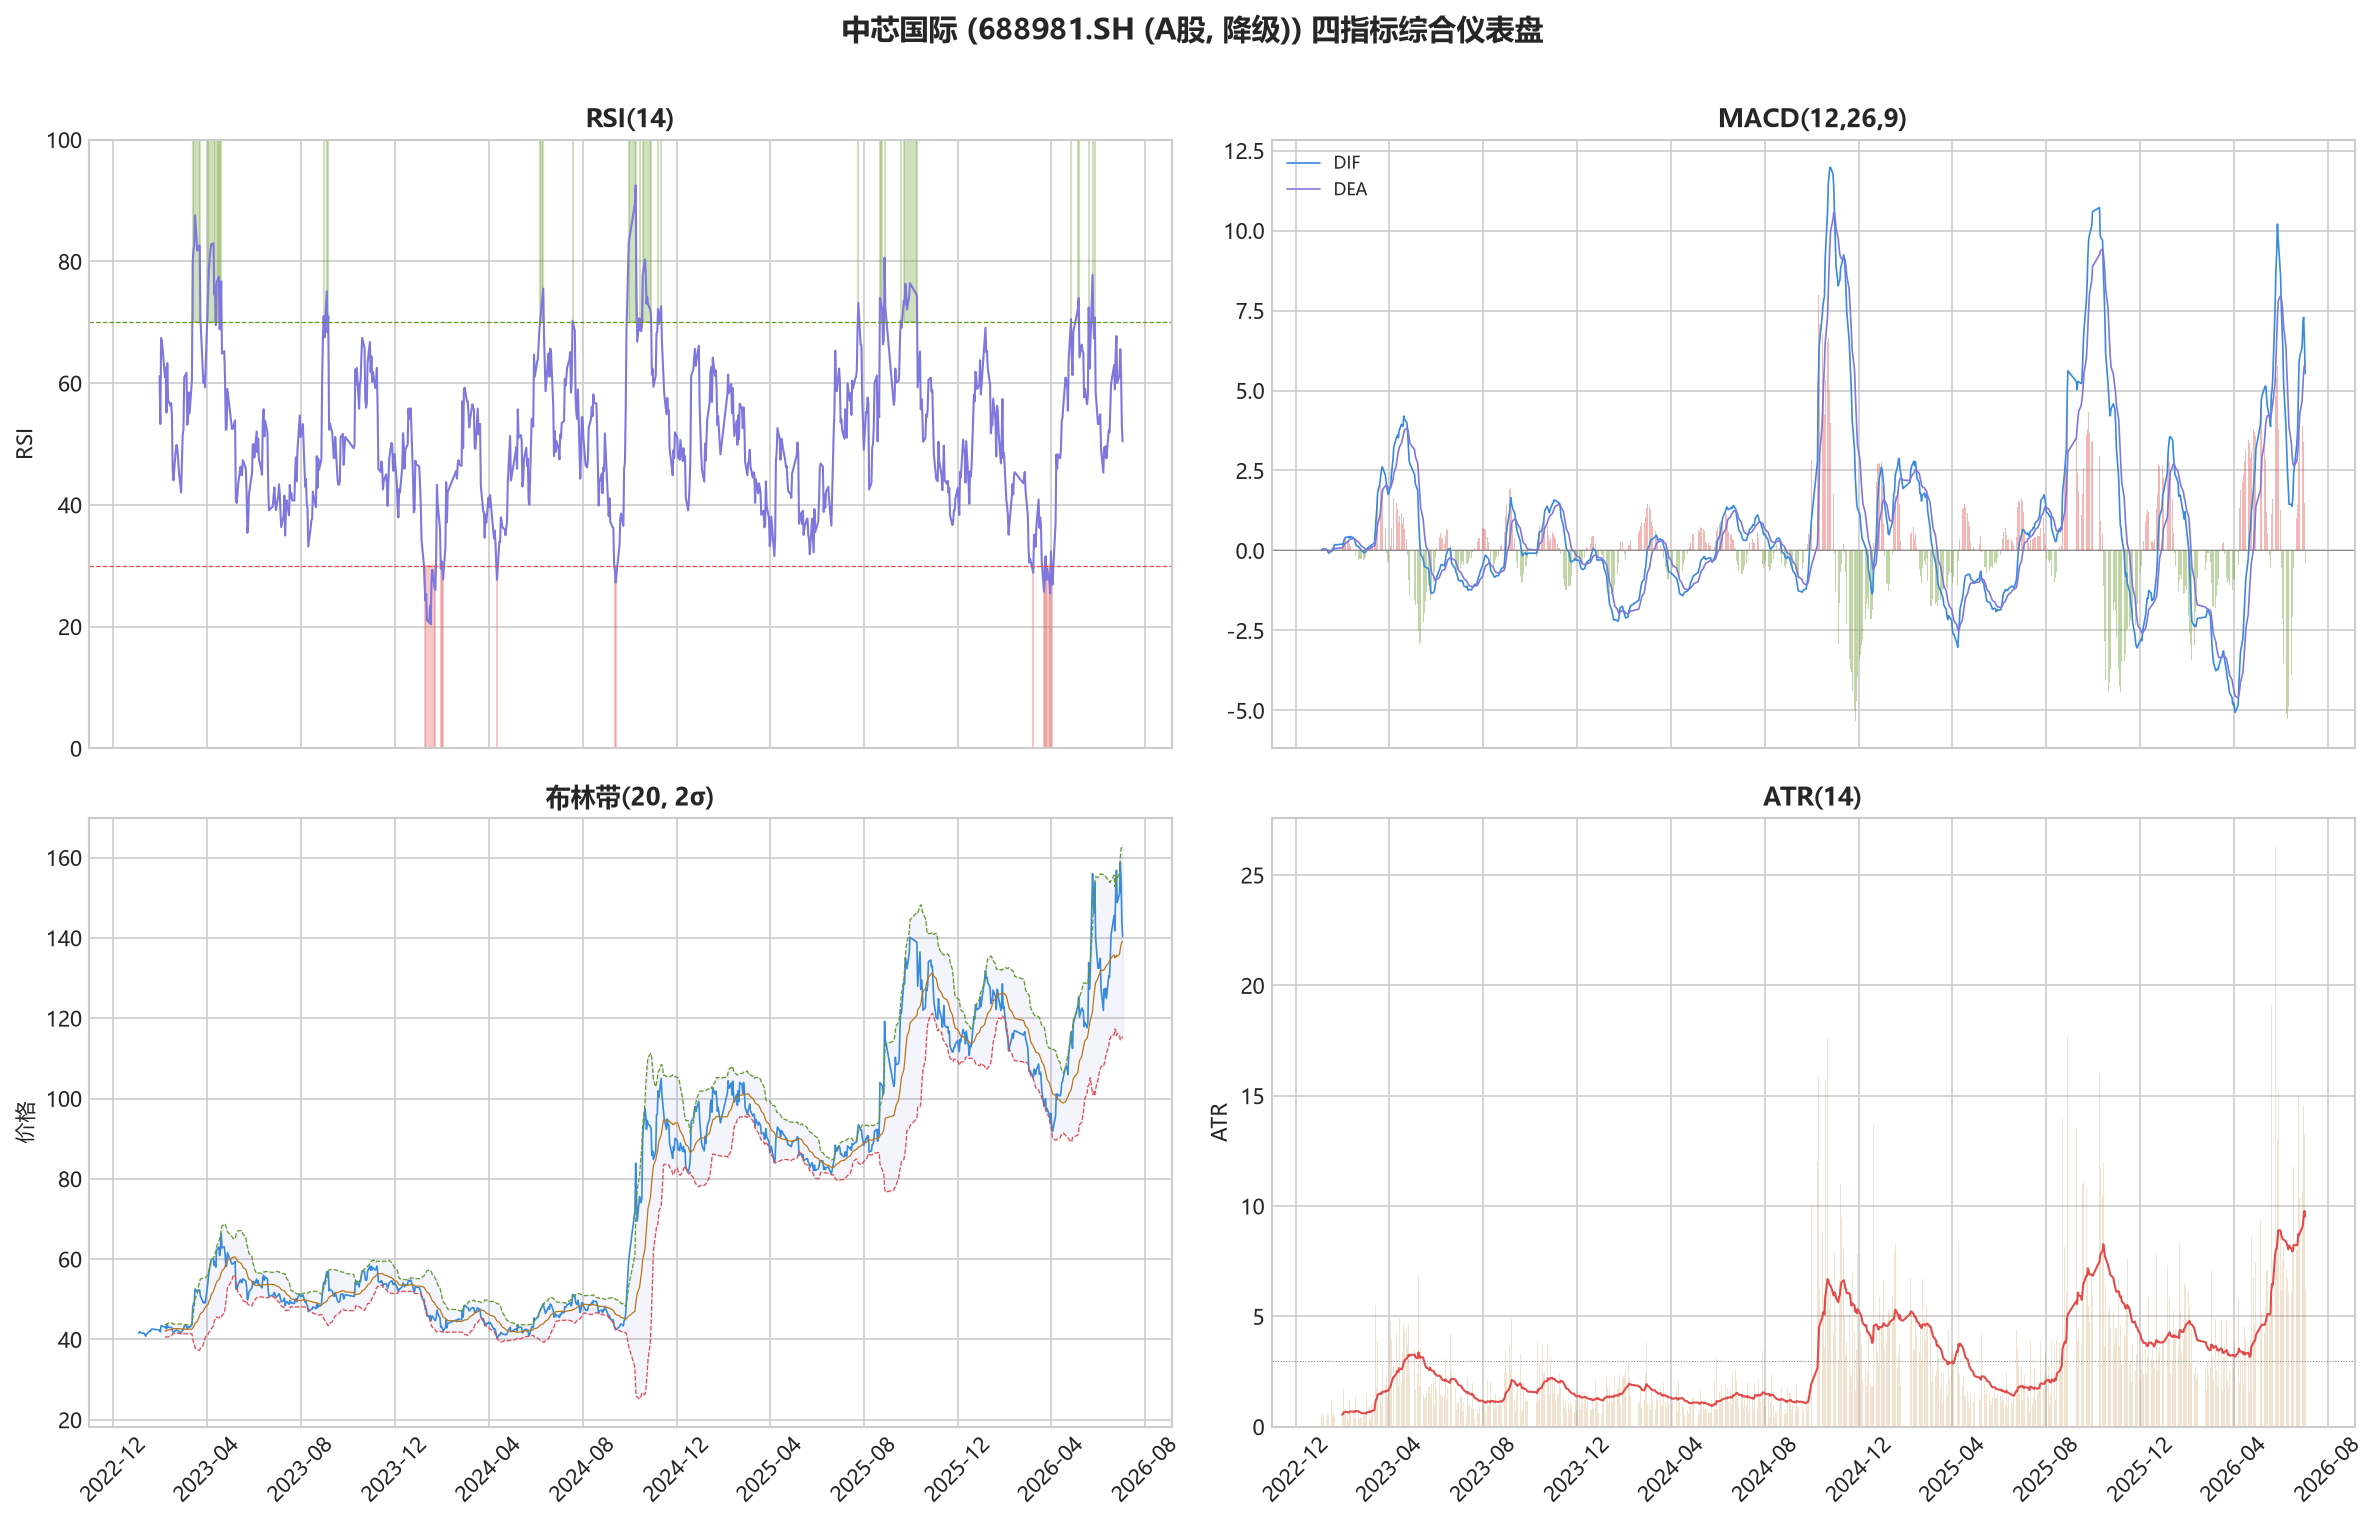

图表已保存: figures/dashboard.png


In [13]:
# === 综合仪表盘 (2×2 网格) ===
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

# 左上: RSI
ax = axes[0, 0]
ax.plot(df.index, df['rsi_14'], color=COLOR_SIGNAL, linewidth=1)
ax.axhline(y=70, color=COLOR_DOWN, linestyle='--', linewidth=0.6)
ax.axhline(y=30, color=COLOR_UP, linestyle='--', linewidth=0.6)
ax.fill_between(df.index, 70, 100, where=df['rsi_14'] > 70, alpha=0.3, color=COLOR_DOWN)
ax.fill_between(df.index, 0, 30, where=df['rsi_14'] < 30, alpha=0.3, color=COLOR_UP)
ax.set_ylim(0, 100)
ax.set_title('RSI(14)', fontsize=12, fontweight='bold')
ax.set_ylabel('RSI')

# 右上: MACD
ax = axes[0, 1]
macd_colors = [COLOR_UP if v >= 0 else COLOR_DOWN for v in df['macd_hist']]
ax.bar(df.index, df['macd_hist'], color=macd_colors, width=1, alpha=0.4)
ax.plot(df.index, df['dif'], color=COLOR_PRICE, linewidth=0.8, label='DIF')
ax.plot(df.index, df['dea'], color=COLOR_SIGNAL, linewidth=0.8, label='DEA')
ax.axhline(y=0, color='gray', linewidth=0.4)
ax.set_title('MACD(12,26,9)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=8)

# 左下: 布林带
ax = axes[1, 0]
ax.plot(df.index, df['close'], color=COLOR_PRICE, linewidth=0.8, label='收盘价')
ax.plot(df.index, df['bb_upper'], color=COLOR_DOWN, linewidth=0.6, linestyle='--')
ax.plot(df.index, df['bb_mid'], color=COLOR_ACCENT, linewidth=0.6)
ax.plot(df.index, df['bb_lower'], color=COLOR_UP, linewidth=0.6, linestyle='--')
ax.fill_between(df.index, df['bb_lower'], df['bb_upper'], alpha=0.08, color=COLOR_SIGNAL)
ax.set_title('布林带(20, 2σ)', fontsize=12, fontweight='bold')
ax.set_ylabel('价格')

# 右下: ATR
ax = axes[1, 1]
ax.bar(df.index, df['tr'], color=COLOR_ACCENT, width=1, alpha=0.2)
ax.plot(df.index, df['atr_14'], color=COLOR_UP, linewidth=1, label='ATR(14)')
ax.axhline(y=atr_mean, color='gray', linestyle=':', linewidth=0.5)
ax.set_title('ATR(14)', fontsize=12, fontweight='bold')
ax.set_ylabel('ATR')

# 统一 X 轴格式
for ax in axes[1]:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    for label in ax.get_xticklabels():
        label.set_rotation(45)

fig.suptitle(f'中芯国际 ({DATA_SOURCE}) 四指标综合仪表盘', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dashboard.png'), bbox_inches='tight')
plt.show()
print("图表已保存: figures/dashboard.png")

In [14]:
# === 信号汇总表 (最近 30 个交易日) ===

def rsi_signal(val):
    if val > 70: return '超买'
    elif val < 30: return '超卖'
    elif val > 50: return '偏多'
    else: return '偏空'

def macd_signal(row):
    if row['dif'] > row['dea'] and row['macd_hist'] > 0:
        return '多头'
    elif row['dif'] < row['dea'] and row['macd_hist'] < 0:
        return '空头'
    else:
        return '转折'

def bb_signal(pct_b):
    if pct_b > 1.0: return '突破上轨'
    elif pct_b > 0.8: return '接近上轨'
    elif pct_b < 0.0: return '突破下轨'
    elif pct_b < 0.2: return '接近下轨'
    else: return '中轨附近'

# 构建信号表
signal_df = pd.DataFrame(index=df.index[-30:])
signal_df['收盘价'] = df['close'].iloc[-30:].round(2)
signal_df['RSI(14)'] = df['rsi_14'].iloc[-30:].round(2)
signal_df['RSI信号'] = df['rsi_14'].iloc[-30:].apply(rsi_signal)
signal_df['DIF'] = df['dif'].iloc[-30:].round(4)
signal_df['MACD信号'] = df.iloc[-30:].apply(macd_signal, axis=1)
signal_df['布林%B'] = df['bb_pct_b'].iloc[-30:].round(3)
signal_df['布林信号'] = df['bb_pct_b'].iloc[-30:].apply(bb_signal)
signal_df['ATR(14)'] = df['atr_14'].iloc[-30:].round(4)
signal_df['ATR止损价'] = df['stop_loss_2atr'].iloc[-30:].round(2)

# 保存含全部指标的 CSV
indicator_cols = ['open', 'high', 'low', 'close', 'vol', 'pct_chg',
                  'rsi_14', 'dif', 'dea', 'macd_hist',
                  'bb_mid', 'bb_upper', 'bb_lower', 'bb_width', 'bb_pct_b',
                  'tr', 'atr_14', 'stop_loss_2atr']
df[indicator_cols].to_csv(os.path.join(DATA_DIR, '00981HK_indicators.csv'), encoding='utf-8-sig')

print("=== 最近 30 个交易日信号汇总 ===")
print(signal_df.to_string())
print(f"\n含全部指标的 CSV 已保存: data/00981HK_indicators.csv")

# 汇总统计
print(f"\n=== 最近 30 日信号统计 ===")
print(f"RSI: 超买{(signal_df['RSI信号']=='超买').sum()}天, 超卖{(signal_df['RSI信号']=='超卖').sum()}天, 偏多{(signal_df['RSI信号']=='偏多').sum()}天, 偏空{(signal_df['RSI信号']=='偏空').sum()}天")
print(f"MACD: 多头{(signal_df['MACD信号']=='多头').sum()}天, 空头{(signal_df['MACD信号']=='空头').sum()}天, 转折{(signal_df['MACD信号']=='转折').sum()}天")
print(f"布林带: 突破上轨{(signal_df['布林信号']=='突破上轨').sum()}天, 突破下轨{(signal_df['布林信号']=='突破下轨').sum()}天")

=== 最近 30 个交易日信号汇总 ===
               收盘价  RSI(14) RSI信号      DIF MACD信号   布林%B  布林信号  ATR(14)  ATR止损价
trade_date                                                                     
2026-05-22  131.33    65.59    偏多   5.4220     多头  0.921  接近上轨   6.4151  118.50
2026-05-25  156.00    77.81    超买   7.6470     多头  1.323  突破上轨   7.8333  140.33
2026-05-26  149.18    70.37    超买   8.7591     多头  1.055  突破上轨   8.0238  133.13
2026-05-27  146.22    67.36    偏多   9.2944     多头  0.928  接近上轨   8.0593  130.10
2026-05-28  153.70    70.76    超买  10.2046     多头  0.992  接近上轨   8.4157  136.87
2026-05-29  139.91    58.62    偏多   9.7014     多头  0.710  中轨附近   8.9010  122.11
2026-06-01  132.44    53.29    偏多   8.6007     多头  0.551  中轨附近   8.8910  114.66
2026-06-02  132.48    53.31    偏多   7.6434     空头  0.539  中轨附近   8.6988  115.08
2026-06-03  134.00    54.29    偏多   6.9276     空头  0.560  中轨附近   8.5703  116.86
2026-06-04  134.88    54.88    偏多   6.3581     空头  0.568  中轨附近   8.4988  117.88
2026-06-05  127.4

### 总结与判读

#### 四指标特点回顾

| 指标 | 类型 | 擅长场景 | 局限性 |
|------|------|----------|--------|
| **RSI** | 动量震荡 | 震荡市判拐点 | 趋势市中信号失真，可能长期超买/超卖 |
| **MACD** | 趋势跟踪 | 趋势市判方向 | 信号滞后，盘整市频繁假交叉 |
| **布林带** | 波动率通道 | 判突破时机 | 通道宽度需结合历史比较 |
| **ATR** | 波动率度量 | 止损/仓位管理 | 不指示方向，需配合趋势指标 |

#### 组合使用建议

- **MACD 定方向** → 趋势确认
- **布林带定时机** → 突破信号
- **RSI 定拐点** → 超买超卖预警
- **ATR 定止损** → 风险控制

#### 实际应用注意事项

1. **单一指标不构成交易信号**：任何指标都有假信号，需多指标交叉验证
2. **结合基本面**：中芯国际受半导体周期、地缘政策、产能利用率等基本面因素驱动
3. **参数敏感性**：默认参数(14/12-26-9/20-2σ)不一定最优，可根据标的特性调整
4. **回测验证**：实盘前务必对信号策略进行历史回测，评估胜率与盈亏比
5. **港股特性**：港股无涨跌停限制，跳空缺口更频繁，ATR 的意义更为重要

---

> 本 notebook 展示了技术指标的**计算过程与可视化判读**，不构成投资建议。